In [23]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

In [24]:
file_path = '../data/Alesis-Fusion-Clean-Guitar-C3.wav'
audio_data, sample_rate = librosa.load(file_path, sr=None)

print(f"Sample Rate: {sample_rate}")
print(f"Audio Shape: {audio_data.shape}")

Sample Rate: 44100
Audio Shape: (196783,)


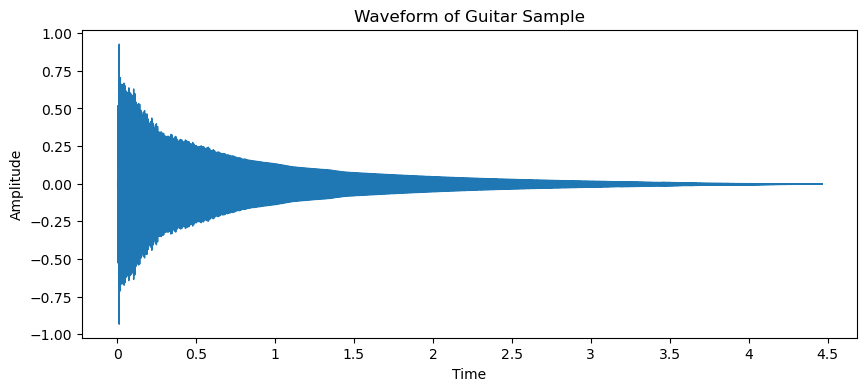

In [25]:
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio_data, sr=sample_rate)
plt.title("Waveform of Guitar Sample")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

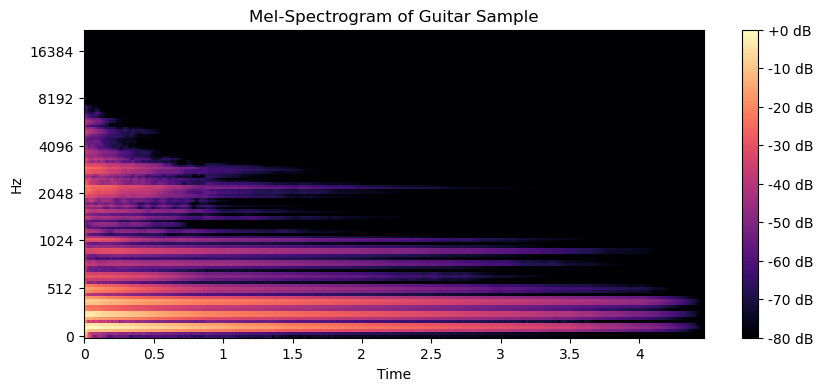

In [26]:
mel_spectogram = librosa.feature.melspectrogram(y=audio_data, sr=sample_rate, n_mels = 128)
mel_spectogram_db = librosa.power_to_db(mel_spectogram, ref = np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spectogram_db, sr=sample_rate, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel-Spectrogram of Guitar Sample")
plt.savefig("../data/features/mel_spectrogram.png")
plt.show()

In [27]:
# convert mel_spectrogram_db to a numpy array
np.save("../data/features/mel_spectrogram.npy", mel_spectogram_db)

In [28]:
# reconvert the numpy array to audio and save it
reconstructed_audio = librosa.feature.inverse.mel_to_audio(mel_spectogram_db)


In [30]:
#save the reconstructed audio to a file

from scipy.io.wavfile import write
write("../data/features/reconstructed_audio.wav", sample_rate, reconstructed_audio)
